Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [119]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application


## Reading in data

In [ ]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# defining spherical harmonic degree cutoff
nmax_list = np.arange(3, 15, 2)

hankel=False
embedding_d=10

weight_flag = True

dmd_type_used = 'exact'

bopdmd=False
bopdmd_params = {
    "num_trials":50,
    "trial_size":0.9,
    "remove_bad_bags":True,
}

fbdmd = False

ensemble_flag = False

svd_rank_list = [-1, 0.9, 0.99, 0.999, 0.9999,2*len(mode_numbers), 0]
svd_rank_list = [int(val) for val in np.arange(10, 50, 4)]


## Running pipeline (loading data, run DMD, recover modes)

In [ ]:
# BELOW:
# Runs pipeline and retrieves results for:
#   - specified nmax
#   - specified DMD setup
#   - specified SVD rank truncation

# -------------------------------------
# LOADING IN DATA
# -------------------------------------

# CHAOS gauss coeffs
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=nmax)

# Synthetic gauss coeffs
gnm_syn_ideal, gnm_syn, syn_suite_info = Synthetic_Full_SV_Record_Obtain(mode_numbers, times_used_relative, nmax=nmax)

# PREPARING DATA

# applying just to ideal synthetic record - equivalent to others
gnm_syn_non_wave = Non_Wave_Spectral_Infill(gnm_chaos, gnm_syn, dt_sample=dt_sample)
gnm_syn_infilled = gnm_syn + gnm_syn_non_wave

# PROJECTING DATA TO PHYSICAL SV GRID
A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax)

def Pipeline_Run(nmax, svd_rank):


    # -------------------------------------
    # OBTAINING DMD MATCH RESULTS
    # -------------------------------------

    # now looping through pipeline
    # want: 1 ideal test, 1 resolved test, 1 background test, 100 noise ensembles.

    results_dict = {}

    record_dict = {
        "ideal":gnm_syn_ideal,
        "resolved":gnm_syn,
        "background":gnm_syn_infilled,
    }

    for record_key in record_dict:

        record_used = record_dict[record_key]

        # projecting to physical space
        record_physical = A_r @ record_used.T

        # running DMD
        recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd, weighted=weight_flag)

        # matching input and output modes
        match_results = Match_Input_Output_Modes(syn_suite_info, recovered_modes, nmax=nmax)

        results_dict[record_key] = match_results

    # -------------------------------------
    # ENSEMBLE RESULTS
    # -------------------------------------

    if ensemble_flag:

        n_ensembles = 100

        perturbation_path = (
            Path(CHAOS_COV_DIR)
            / (
                "CHAOS_0806_nmax15_SV_nTyr_perturbations_N1000_Nt53.h5"
            )
        )

        ensemble_results = {}

        for mode_key in syn_suite_info:
            ensemble_results[mode_key] = {
                "period_error":[],
                "similarity":[],
                "no_match_count":0,
            }

        with h5py.File(perturbation_path, "r") as f:

            for i in tqdm(range(n_ensembles), desc="ensembles"):

                gnm_perturbation_i = f["perturbations"][i, :, :].T

                # truncating to nmax
                gnm_perturbation_i = Truncate_Gauss_Coeffs(gnm_perturbation_i, tmax=nmax)
                gnm_perturbed_i = gnm_syn + gnm_perturbation_i

                # projecting to physical space
                record_physical = A_r @ gnm_perturbed_i.T

                # running DMD
                recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd, weighted=weight_flag)

                # matching input and output modes
                match_results = Match_Input_Output_Modes(syn_suite_info, recovered_modes, nmax=nmax, record_key='ensemble')

                for mode_key in match_results:
                    if match_results[mode_key]:
                        ensemble_results[mode_key]["period_error"].append(match_results[mode_key]["period_error"])
                        ensemble_results[mode_key]["similarity"].append(match_results[mode_key]["similarity"])
                    else:
                        ensemble_results[mode_key]["no_match_count"] += 1

        results_dict["ensemble"] = ensemble_results

    return(results_dict)


In [139]:
print(svd_rank_list)

[10, 14, 18, 22, 26, 30, 34, 38, 42, 46]


In [152]:
%%capture

svd_rank_list = [-1, 0.99, 0.999, 0.9999,2*len(mode_numbers), 0, 10, 20, 30, 40, 50]

total_results = np.zeros((len(svd_rank_list), len(nmax_list)))

for i, svd_rank in enumerate(svd_rank_list):
    for j, nmax in enumerate(nmax_list):
        results_run = Pipeline_Run(nmax, svd_rank)
        match_count = results_run["resolved"]["match_count"]
        total_results[i, j] = match_count

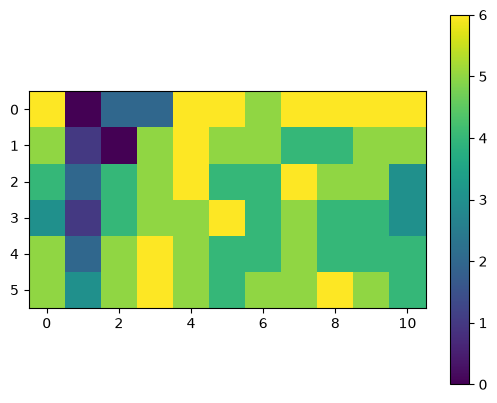

In [153]:
plt.imshow(total_results.T)
plt.colorbar()
plt.show()

## Comparing recovery success


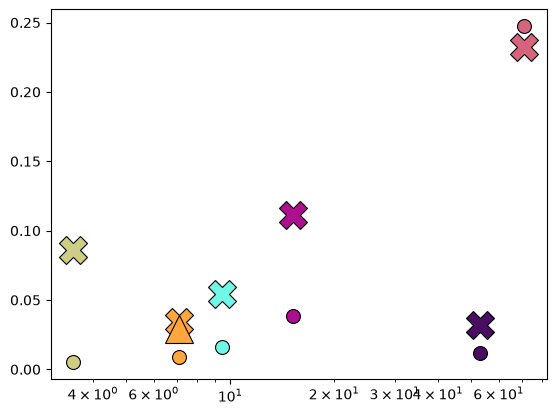

In [150]:
# looking at each record outcomes
plot_rules = {
    "ideal":{
        "shape":"o",
        "size":10,
    },
    "resolved":{
        "shape":"X",
        "size":20,
    },
    "background":{
        "shape":"^",
        "size":20,
    },
    "ensemble":{
        "shape":".",
        "size":5,
    }
}
results_dict =  Pipeline_Run(nmax_list[-1], svd_rank_list[3])

mode_colours = {}
rng = np.random.default_rng(5)

for mode_key in mode_numbers:

    random_colour = rng.random(3)
    mode_colours[mode_key] = random_colour

for result_type in results_dict:

    result_info = results_dict[result_type]

    for mode_key in mode_numbers:

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]
        mode_result = result_info[mode_key]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        period_error, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(period_error), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')




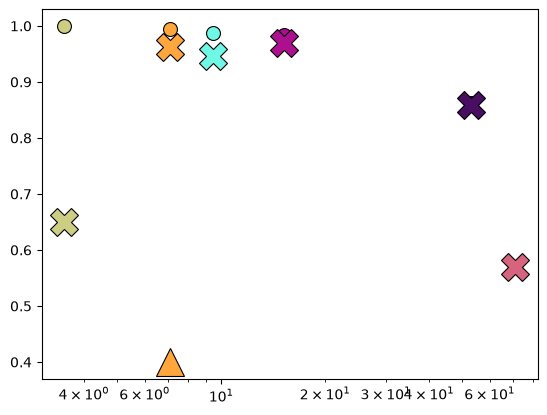

In [151]:

for result_type in results_dict:

    result_info = results_dict[result_type]

    for mode_key in mode_numbers:

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]
        mode_result = result_info[mode_key]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        similarity, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(similarity), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')